In [1]:
# Install any missing libraries
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "seaborn"])

CompletedProcess(args=['pip', 'install', 'pandas', 'matplotlib', 'seaborn'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

print("All libraries loaded successfully! ✅")

All libraries loaded successfully! ✅


In [3]:
# Point this to your raw_data folder
path = r"C:\Users\raj97\Desktop\cyclistic_capstone\raw_data"

# Load and combine all CSV files into one dataframe
all_files = glob.glob(os.path.join(path, "*.csv"))
df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

print(f"Total rows loaded: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(df.columns.tolist())

Total rows loaded: 6,068,796
Total columns: 13
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']


In [4]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,41.940000,-87.640000,member
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,41.830000,-87.670000,member
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,41.890000,-87.630000,member


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6068796 entries, 0 to 6068795
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 601.9+ MB


In [6]:
# Count missing values per column
df.isnull().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1286941
start_station_id      1286941
end_station_name      1353498
end_station_id        1353498
start_lat                   0
start_lng                   0
end_lat                  6146
end_lng                  6146
member_casual               0
dtype: int64

In [7]:
# Convert started_at and ended_at to datetime
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

print("Date columns converted ✅")
print(df[['started_at', 'ended_at']].dtypes)

Date columns converted ✅
started_at    datetime64[ns]
ended_at      datetime64[ns]
dtype: object


In [8]:
# Ride length in minutes
df['ride_length'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

# Day of week (0 = Monday, 6 = Sunday)
df['day_of_week'] = df['started_at'].dt.day_name()

# Month and hour (useful for trend analysis)
df['month'] = df['started_at'].dt.month_name()
df['hour'] = df['started_at'].dt.hour

print("New columns added ✅")
df[['ride_length', 'day_of_week', 'month', 'hour']].head()

New columns added ✅


,ride_length,day_of_week,month,hour
0,15.021400,Saturday,January,9
1,7.605467,Thursday,January,14
2,6.739167,Tuesday,January,12
3,30.836433,Monday,January,16
4,78.447200,Saturday,January,18


In [9]:
# Remove rides with negative or zero ride length (data errors)
before = len(df)
df = df[df['ride_length'] > 0]

# Remove rides longer than 24 hours (likely abandoned bikes)
df = df[df['ride_length'] < 1440]

after = len(df)
print(f"Rows removed: {before - after:,}")
print(f"Clean rows remaining: {after:,}")

Rows removed: 6,162
Clean rows remaining: 6,062,634


In [10]:
# Drop rows missing end coordinates
before = len(df)
df = df.dropna(subset=['end_lat', 'end_lng'])

after = len(df)
print(f"Rows removed: {before - after:,}")
print(f"Clean rows remaining: {after:,}")

Rows removed: 228
Clean rows remaining: 6,062,406


In [11]:
# Final check
print(f"Dataset shape: {df.shape}")
print(f"\nRide length stats (minutes):")
print(df['ride_length'].describe().round(2))
print(f"\nRider type breakdown:")
print(df['member_casual'].value_counts())
print(f"\nBike types:")
print(df['rideable_type'].value_counts())

Dataset shape: (6062406, 17)

Ride length stats (minutes):
count    6062406.00
mean          14.40
std           28.40
min            0.00
25%            5.34
50%            9.33
75%           16.40
max         1439.98
Name: ride_length, dtype: float64

Rider type breakdown:
member_casual
member    3920615
casual    2141791
Name: count, dtype: int64

Bike types:
rideable_type
electric_bike    3993822
classic_bike     2068584
Name: count, dtype: int64


In [12]:
ride_length_comparison = df.groupby('member_casual')['ride_length'].agg(['mean', 'median']).round(2)
ride_length_comparison.columns = ['Mean (mins)', 'Median (mins)']
print(ride_length_comparison)

               Mean (mins)  Median (mins)
member_casual                            
casual               18.87          11.22
member               11.95           8.53


In [13]:
# Set correct day order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

rides_by_day = df.groupby(['member_casual', 'day_of_week']).size().unstack()
rides_by_day = rides_by_day[day_order]
print(rides_by_day)

day_of_week    Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
member_casual                                                                
casual         246396   244738     242438    281469  335332    434799  356619
member         551900   631775     621276    641450  573474    483385  417355


In [14]:
rides_by_hour = df.groupby(['member_casual', 'hour']).size().unstack()
print(rides_by_hour)

hour              0      1      2     3     4      5       6       7       8   \
member_casual                                                                   
casual         41386  26525  17652  9729  7837  12428   28832   53434   76564   
member         34937  21530  13009  8573  9669  37865  110906  221124  286509   

hour               9   ...      14      15      16      17      18      19  \
member_casual          ...                                                   
casual          75589  ...  148336  165430  190213  206364  176218  130534   
member         183149  ...  207072  262562  373715  425645  327735  225344   

hour               20      21     22     23  
member_casual                                
casual          93644   80241  67429  48348  
member         156124  121382  87762  54521  

[2 rows x 24 columns]


In [15]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

rides_by_month = df.groupby(['member_casual', 'month']).size().unstack()
rides_by_month = rides_by_month[month_order]
print(rides_by_month)

month          January  February   March   April     May    June    July  \
member_casual                                                              
casual           24654     41083   87619  240178  182256  291111  322488   
member          112923    160241  229117  578761  319748  386703  439963   

month          August  September  October  November  December  
member_casual                                                  
casual         337236     264759   223562     98841     28004  
member         452350     449199   421915    257280    112415  


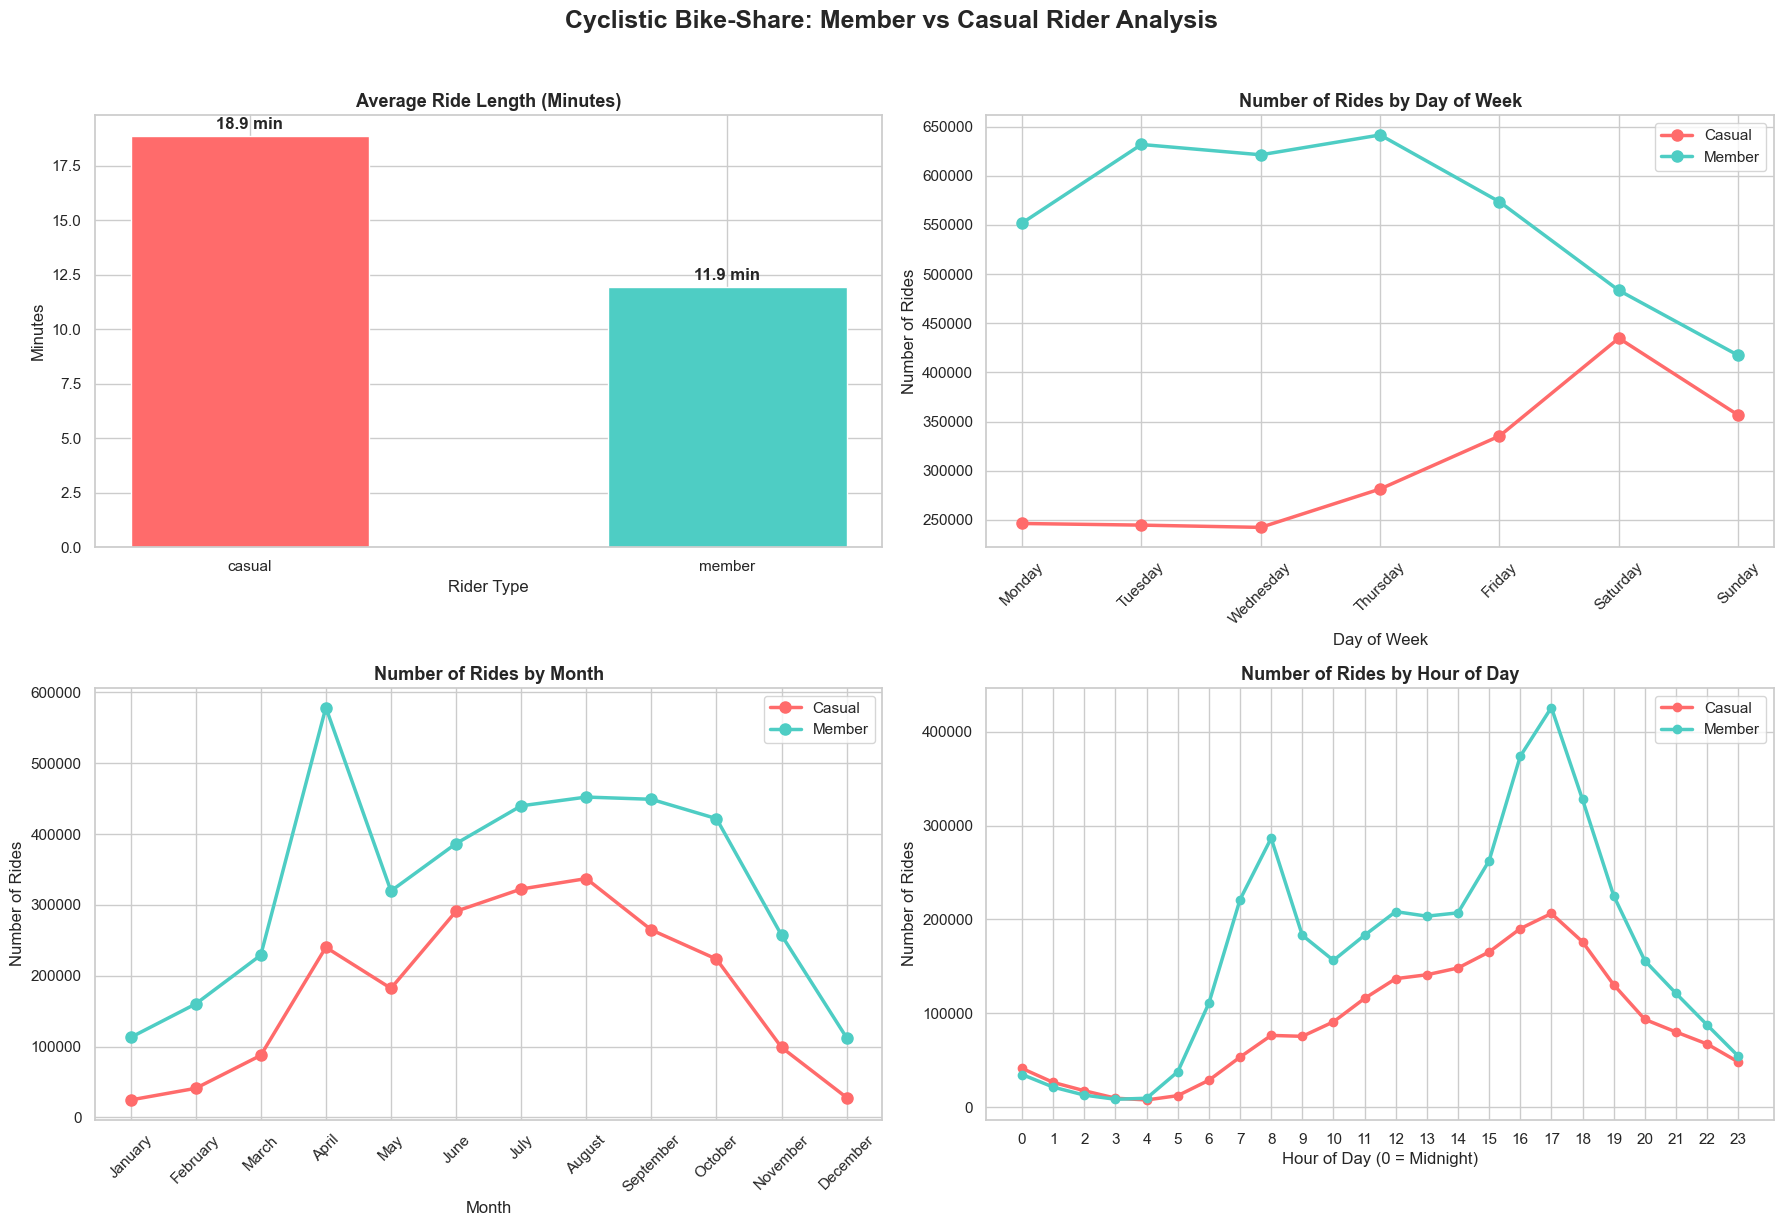

Charts saved! ✅


In [17]:
# Set style
sns.set_theme(style="whitegrid")
colors = {'casual': '#FF6B6B', 'member': '#4ECDC4'}
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Cyclistic Bike-Share: Member vs Casual Rider Analysis', 
             fontsize=18, fontweight='bold', y=1.02)

# --- Chart 1: Average Ride Length ---
ax1 = axes[0, 0]
ride_avg = df.groupby('member_casual')['ride_length'].mean().round(2)
bars = ax1.bar(ride_avg.index, ride_avg.values, 
               color=[colors[x] for x in ride_avg.index], width=0.5)
ax1.set_title('Average Ride Length (Minutes)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Rider Type')
ax1.set_ylabel('Minutes')
for bar, val in zip(bars, ride_avg.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f} min', ha='center', fontweight='bold')

# --- Chart 2: Rides by Day of Week ---
ax2 = axes[0, 1]
for rider_type, color in colors.items():
    data = df[df['member_casual'] == rider_type].groupby('day_of_week').size()
    data = data.reindex(day_order)
    ax2.plot(day_order, data.values, marker='o', label=rider_type.capitalize(),
             color=color, linewidth=2.5, markersize=8)
ax2.set_title('Number of Rides by Day of Week', fontsize=13, fontweight='bold')
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Number of Rides')
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

# --- Chart 3: Rides by Month ---
ax3 = axes[1, 0]
for rider_type, color in colors.items():
    data = df[df['member_casual'] == rider_type].groupby('month').size()
    data = data.reindex(month_order)
    ax3.plot(month_order, data.values, marker='o', label=rider_type.capitalize(),
             color=color, linewidth=2.5, markersize=8)
ax3.set_title('Number of Rides by Month', fontsize=13, fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Number of Rides')
ax3.legend()
ax3.tick_params(axis='x', rotation=45)

# --- Chart 4: Rides by Hour ---
ax4 = axes[1, 1]
for rider_type, color in colors.items():
    data = df[df['member_casual'] == rider_type].groupby('hour').size()
    ax4.plot(range(24), data.values, marker='o', label=rider_type.capitalize(),
             color=color, linewidth=2.5, markersize=6)
ax4.set_title('Number of Rides by Hour of Day', fontsize=13, fontweight='bold')
ax4.set_xlabel('Hour of Day (0 = Midnight)')
ax4.set_ylabel('Number of Rides')
ax4.set_xticks(range(24))
ax4.legend()

plt.tight_layout()
plt.savefig(r'C:\Users\raj97\Desktop\cyclistic_capstone\cyclistic_analysis.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved! ✅")

In [18]:
summary = """
==============================================
CYCLISTIC BIKE-SHARE ANALYSIS — KEY FINDINGS
==============================================

FINDING 1: Usage Pattern Differences
--------------------------------------
- Members ride primarily on WEEKDAYS (commuters)
  Peak days: Tuesday, Wednesday, Thursday
- Casual riders ride primarily on WEEKENDS (leisure)
  Peak days: Saturday, Sunday
- Members show clear 8am & 5pm commute spikes
- Casual riders gradually build through the day

FINDING 2: Ride Duration
--------------------------------------
- Casual riders average 18.87 minutes per ride
- Members average 11.95 minutes per ride
- Casuals ride 58% longer than members
- Suggests leisure/exploratory riding vs purposeful commuting

FINDING 3: Seasonality
--------------------------------------
- Both groups peak in summer (July/August)
- Casual ridership nearly disappears in winter
  (28,004 rides in December vs 337,236 in August)
- Members stay more consistent year-round
- Suggests casuals are fair-weather/tourist riders

==============================================
TOP 3 RECOMMENDATIONS
==============================================

RECOMMENDATION 1: Weekend-to-Membership Conversion
--------------------------------------
Launch a targeted campaign specifically on weekends
at high-traffic stations. Offer a discounted first
month of membership to casual riders who scan a QR
code at docking stations on Saturdays and Sundays.
Messaging: "You already ride on weekends — why not
save money all year?"

RECOMMENDATION 2: Seasonal Urgency Campaign
--------------------------------------
Launch a spring membership drive in March-April as
casual ridership starts climbing. Offer a summer
promotion: "Join before June and get your first
month free." This captures casual riders at the
moment they are returning to the app.

RECOMMENDATION 3: Ride Duration Incentive Program
--------------------------------------
Since casuals take longer rides, introduce a
"Ride Rewards" program where long rides earn
credits toward membership discounts. This directly
appeals to casual riders' existing behavior and
creates a natural bridge toward annual membership.

==============================================
"""

print(summary)


CYCLISTIC BIKE-SHARE ANALYSIS — KEY FINDINGS

FINDING 1: Usage Pattern Differences
--------------------------------------
- Members ride primarily on WEEKDAYS (commuters)
  Peak days: Tuesday, Wednesday, Thursday
- Casual riders ride primarily on WEEKENDS (leisure)
  Peak days: Saturday, Sunday
- Members show clear 8am & 5pm commute spikes
- Casual riders gradually build through the day

FINDING 2: Ride Duration
--------------------------------------
- Casual riders average 18.87 minutes per ride
- Members average 11.95 minutes per ride
- Casuals ride 58% longer than members
- Suggests leisure/exploratory riding vs purposeful commuting

FINDING 3: Seasonality
--------------------------------------
- Both groups peak in summer (July/August)
- Casual ridership nearly disappears in winter
  (28,004 rides in December vs 337,236 in August)
- Members stay more consistent year-round
- Suggests casuals are fair-weather/tourist riders

TOP 3 RECOMMENDATIONS

RECOMMENDATION 1: Weekend-to-Member

In [20]:
# Save your clean dataset summary to CSV
summary_df = df.groupby('member_casual').agg(
    total_rides=('ride_id', 'count'),
    avg_ride_length=('ride_length', 'mean'),
    median_ride_length=('ride_length', 'median')
).round(2)

summary_df.to_csv(r'C:\Users\raj97\Desktop\cyclistic_capstone\analysis_summary.csv')
print("Summary exported! ✅")
print(summary_df)

Summary exported! ✅
               total_rides  avg_ride_length  median_ride_length
member_casual                                                  
casual             2141791            18.87               11.22
member             3920615            11.95                8.53
